# Phase 13: Request Schema

**Project:** Hospital Patient Helpdesk Chatbot  
**Purpose:** Define and validate the user input format for the backend `/chat` endpoint.

This notebook imports `07_backend/13_request_schema.py`. The module is framework-independent, with optional Pydantic model generation when the dependency is installed.


## Inputs and numbered outputs

**Input**

- `01_data/sample_queries/test_questions.csv`: approved synthetic questions used as valid request examples.

**Outputs**

- `13_request_validation_results.json`: normalized valid requests and rejected invalid requests.
- `13_request_schema_report.json`: totals, error counts, configuration, and dependency availability.
- `13_request_schema_audit.csv`: compact validation rows without full question text.
- `13_failed_request_schema_checks.json`: invalid request numbers and error messages.
- `plots/13_question_length_distribution.png`: request question length distribution.
- `plots/13_request_validation_outcomes.png`: valid versus invalid counts.


In [8]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    resolved = start.resolve()
    candidates = []
    for directory in (resolved, *resolved.parents):
        candidates.extend((directory, directory / "hospital_patient_helpdesk_chatbot"))
    for candidate in candidates:
        module_path = candidate / "07_backend" / "13_request_schema.py"
        sample_path = candidate / "01_data" / "sample_queries" / "test_questions.csv"
        if module_path.is_file() and sample_path.is_file():
            return candidate
    raise FileNotFoundError("Could not locate the Hospital Patient Helpdesk Chatbot project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODULE_PATH = PROJECT_ROOT / "07_backend" / "13_request_schema.py"
SAMPLE_PATH = PROJECT_ROOT / "01_data" / "sample_queries" / "test_questions.csv"
OUTPUT_DIR = PROJECT_ROOT / "01_data" / "processed"

spec = importlib.util.spec_from_file_location("phase13_request_schema", MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load module: {MODULE_PATH}")
request_schema = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = request_schema
spec.loader.exec_module(request_schema)

print(f"Project root: {PROJECT_ROOT}")
print(f"Request schema module: {MODULE_PATH}")
print(f"Pydantic available: {importlib.util.find_spec('pydantic') is not None}")


Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
Request schema module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\07_backend\13_request_schema.py
Pydantic available: False


## Canonical request contract

The accepted request contains `question` plus optional filters and metadata: `department`, `content_category`, `session_id`, `language`, `channel`, and `urgency`. Unknown fields are ignored with a warning so sample-evaluation columns do not enter the API contract.


In [9]:
payload = {
    "question": "  Where   is the cardiology department?  ",
    "department": " Cardiology ",
    "session_id": "demo-session-001",
    "language": "en",
    "channel": "notebook",
    "urgency": "routine",
    "extra_column": "ignored",
}
result = request_schema.validate_request_payload(payload)

assert result.valid is True
assert result.normalized_request.question == "Where is the cardiology department?"
assert result.rejected_fields == ["extra_column"]

print(json.dumps(result.__dict__, default=lambda value: value.__dict__, indent=2))


{
  "request_number": 1,
  "valid": true,
  "normalized_request": {
    "question": "Where is the cardiology department?",
    "department": "Cardiology",
    "content_category": null,
    "session_id": "demo-session-001",
    "language": "en",
    "channel": "notebook",
    "urgency": "routine"
  },
  "errors": [],
  "warnings": [
    "Unknown fields were ignored: extra_column."
  ],
  "question_characters": 35,
  "rejected_fields": [
    "extra_column"
  ]
}


## Invalid request examples

The schema blocks too-short questions, oversized questions, sensitive identifiers, invalid language tags, invalid urgency values, unsupported characters, and oversized optional filters.


In [10]:
invalid_payloads = [
    {"question": "x"},
    {"question": "A" * 1001},
    {"question": "My SSN is 123-45-6789"},
    {"question": "Where is billing?", "language": "not-a-valid-language-code"},
    {"question": "Where is billing?", "urgency": "soon"},
]

for number, item in enumerate(invalid_payloads, start=1):
    invalid = request_schema.validate_request_payload(item, request_number=number)
    assert invalid.valid is False
    print(f"Case {number}: {invalid.errors}")


Case 1: ['question must contain at least 2 characters.']
Case 2: ['question must not exceed 1000 characters.']
Case 3: ['question contains sensitive identifiers: ssn.']
Case 4: ['language must be a short language code such as en or en-US.']
Case 5: ['urgency must be one of routine, urgent, or emergency.']


## Optional Pydantic model

When Pydantic is installed, the module can create a request model for FastAPI/OpenAPI. The current interpreter does not include Pydantic, so this cell reports availability without failing the notebook.


In [11]:
if importlib.util.find_spec("pydantic") is not None:
    RequestModel = request_schema.create_pydantic_request_model()
    model = RequestModel(question="Where is cardiology?")
    converted = model.to_chat_request()
    assert converted.question == "Where is cardiology?"
    print(RequestModel)
else:
    try:
        request_schema.create_pydantic_request_model()
    except RuntimeError as error:
        print(f"Expected dependency message: {error}")


Expected dependency message: Pydantic is not installed. Install requirements.txt to create the FastAPI request model.


## Run full Phase 13 validation

The batch uses 12 valid sample questions and 6 adversarial schema cases. The expected result is 13 valid payloads and 5 invalid payloads because the unknown-field case is accepted with a warning.


In [12]:
config = request_schema.RequestValidationConfig()
batch_result = request_schema.run_request_schema_validation(SAMPLE_PATH, OUTPUT_DIR, config)

assert batch_result.input_requests == 18
assert batch_result.valid_requests == 13
assert batch_result.invalid_requests == 5

print(f"Input requests: {batch_result.input_requests}")
print(f"Valid requests: {batch_result.valid_requests}")
print(f"Invalid requests: {batch_result.invalid_requests}")


Input requests: 18
Valid requests: 13
Invalid requests: 5


## Validate artifacts

The report records dependency availability, validation totals, input length statistics, and error counts. The failure file contains only invalid request numbers and validation messages.


In [13]:
results = json.loads(batch_result.results_path.read_text(encoding="utf-8"))
report = json.loads(batch_result.report_path.read_text(encoding="utf-8"))
failures = json.loads(batch_result.failed_path.read_text(encoding="utf-8"))

assert len(results) == 18
assert len(failures) == 5
assert report["valid_requests"] == 13
assert report["invalid_requests"] == 5
assert report["pydantic_available"] is False

print(json.dumps(report, indent=2))


{
  "generated_at_utc": "2026-06-15T19:43:03.423566+00:00",
  "schema_version": "1.0",
  "input_file": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\sample_queries\\test_questions.csv",
  "input_requests": 18,
  "valid_requests": 13,
  "invalid_requests": 5,
  "pydantic_available": false,
  "configuration": {
    "min_question_characters": 2,
    "max_question_characters": 1000,
    "max_optional_filter_characters": 100,
    "allow_sensitive_identifiers": false
  },
  "question_characters": {
    "minimum": 1,
    "maximum": 1001,
    "mean": 84.722,
    "median": 31.0
  },
  "error_counts": {
    "department must not exceed 100 characters.": 1,
    "language must be a short language code such as en or en-US.": 1,
    "question contains sensitive identifiers: ssn.": 1,
    "question must contain at least 2 characters.": 1,
    "question must not exceed 1000 characters.": 1
  },
  "output_files": [
    "13_request_validatio

## Diagnostic plots

The length plot helps tune request size limits. The outcome plot verifies the acceptance and rejection distribution for approved and adversarial samples.


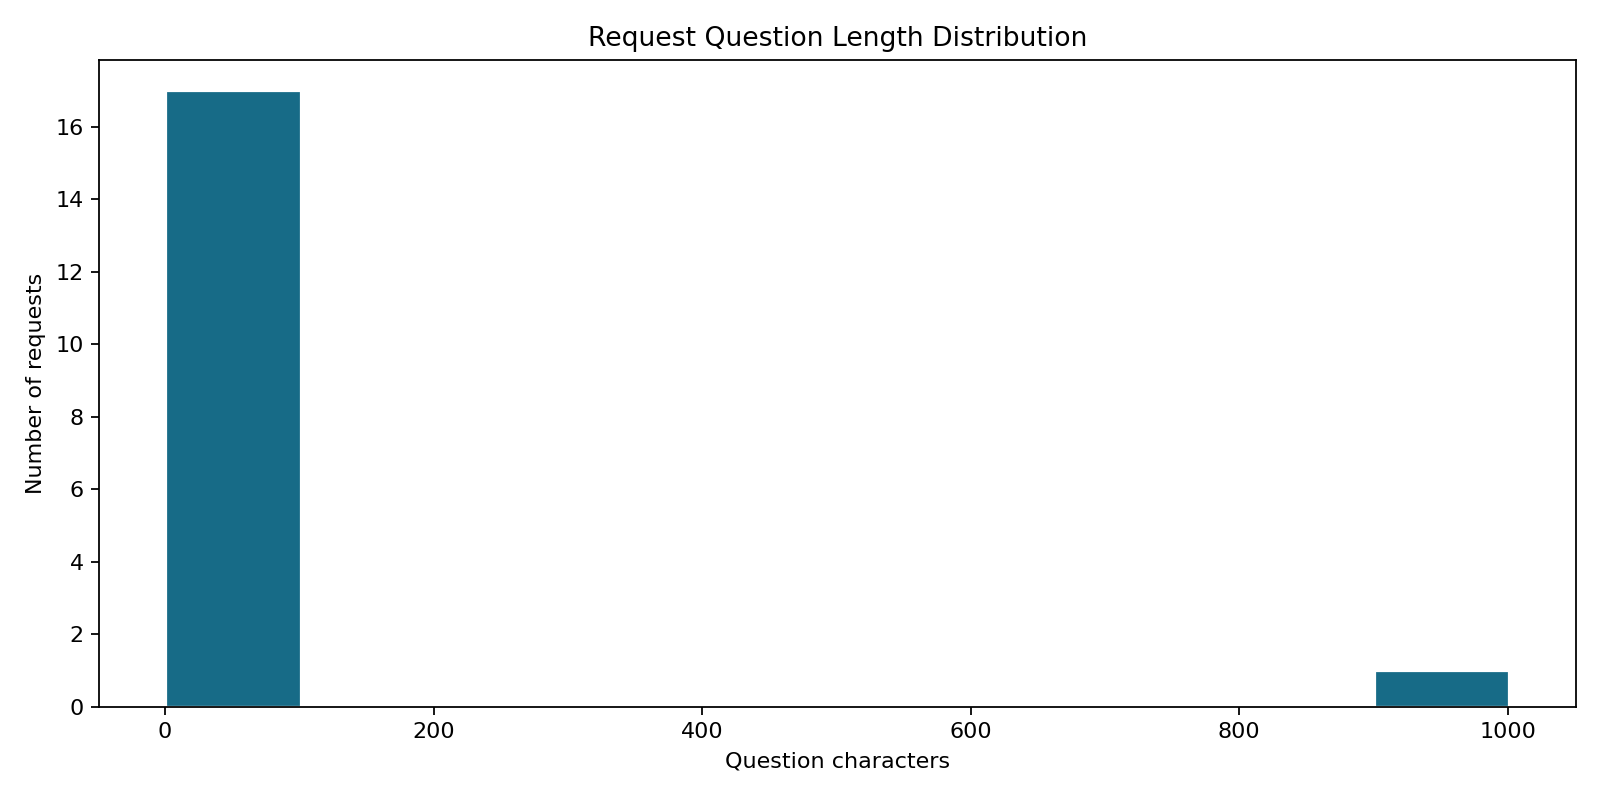

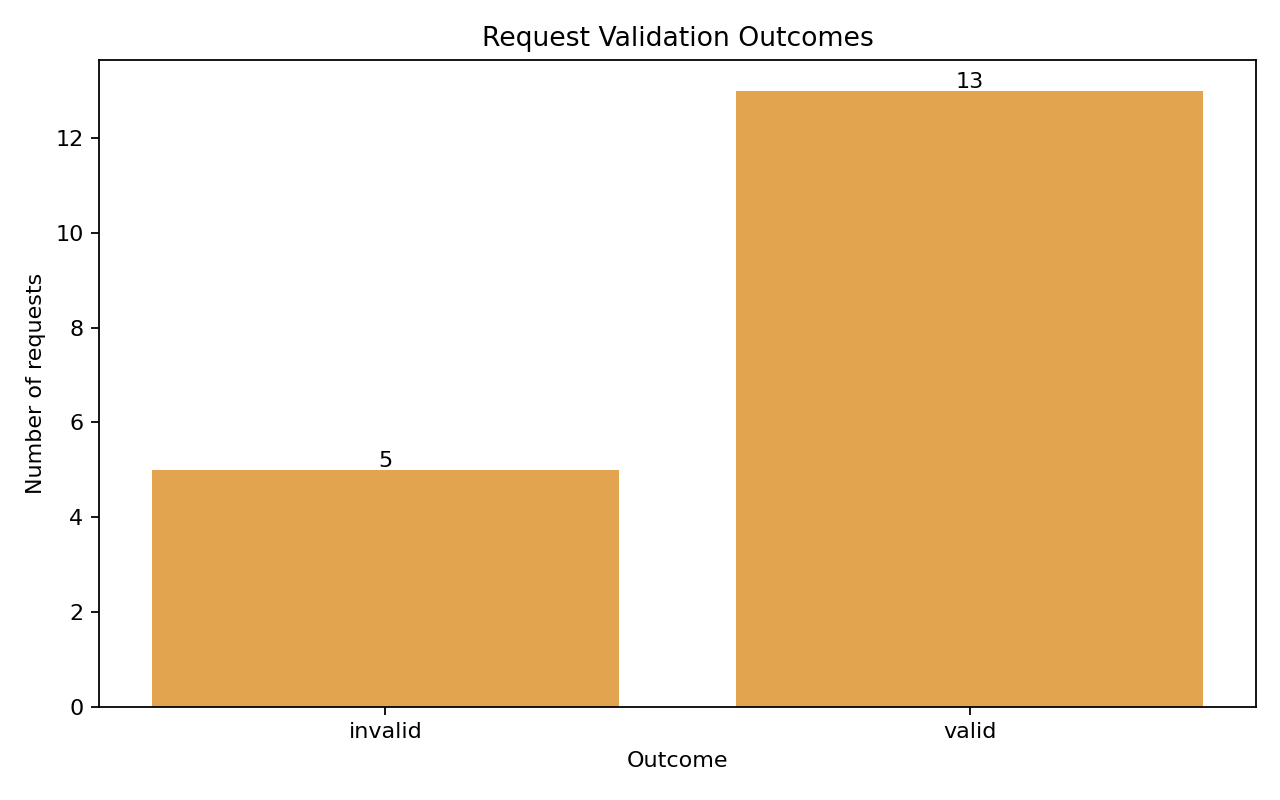

In [14]:
from IPython.display import Image, display

display(Image(filename=str(batch_result.length_plot_path)))
display(Image(filename=str(batch_result.outcomes_plot_path)))


## Notebook and Python module responsibilities

- **Notebook:** explains the schema, demonstrates valid and invalid payloads, checks optional Pydantic support, validates artifacts, and displays plots.
- **Python module:** owns canonical validation rules, optional Pydantic model creation, batch evaluation, reports, audits, failures, plots, and CLI automation.

Both files use the same validation functions, so the notebook stays aligned with the Python module.
